In [ ]:
import numpy as np

arr = np.array([1, 2, 3, 4, 5])

print(arr)

print(np.__version__)


[1 2 3 4 5]
2.3.4


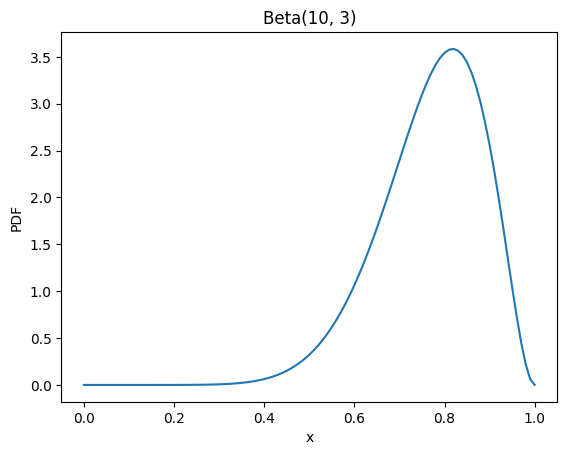

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

Xxx = np.linspace(0, 1, 101)
plt.plot(Xxx, beta(a=10, b=3).pdf(Xxx))
plt.xlabel("x")
plt.ylabel("PDF")
plt.title("Beta(10, 3)")
plt.show()

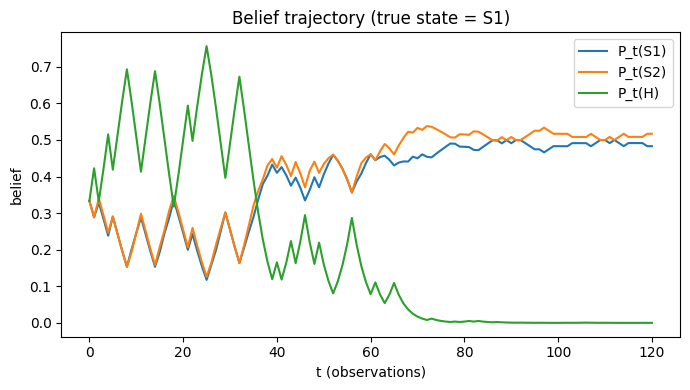

First 10 observations: [np.str_('whistle'), np.str_('scratch'), np.str_('whistle'), np.str_('whistle'), np.str_('cough'), np.str_('whistle'), np.str_('whistle'), np.str_('whistle'), np.str_('cough'), np.str_('scratch')]
x1 = whistle  | p1 (manual) = [0.28873239 0.28873239 0.42253521]  | p1 (sim) = [0.28873239 0.28873239 0.42253521]


In [3]:
# Begin Three States Simulation
# Yurui Zi
# Nov 9th 2025
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
STATES = ["S1", "S2", "H"]
SIGS   = ["cough", "scratch", "whistle"]

# Check a, b, c probabilities within
def check_params(a, b, c):
    assert 0 <= a <= 1 and 0 <= b <= 1 and 0 <= c <= 1, "a,b,c must be in [0,1]"
    assert a + b <= 1, "need a + b ≤ 1"
    assert 2*c <= 1, "need 2c ≤ 1"

# Returns l(x) = [P(x|S1), P(x|S2), P(x|H)] in the order [S1,S2,H].
def likelihood_vector(x, a, b, c):
    if x == "cough":
        return np.array([a, b, c], dtype=float)
    elif x == "scratch":
        return np.array([b, a, c], dtype=float)
    elif x == "whistle":
        return np.array([1-(a+b), 1-(a+b), 1-2*c], dtype=float)
    else:
        raise ValueError("x must be one of {'cough','scratch','whistle'}")

# Samples x_t from P(x|true_state)
def sample_observation(true_state, a, b, c, rng):
    if true_state == "S1":
        probs = [a, b, 1-(a+b)]
    elif true_state == "S2":
        probs = [b, a, 1-(a+b)]
    elif true_state == "H":
        probs = [c, c, 1-2*c]
    else:
        raise ValueError("true_state must be 'S1', 'S2', or 'H'")
    return rng.choice(SIGS, p=probs)

# Updates likelihood using Bayes'
def bayes_update(p_prev, x, a, b, c):
    """p_t = (p_{t-1} ⊙ l(x)) / <p_{t-1}, l(x)>"""
    l = likelihood_vector(x, a, b, c)
    num = p_prev * l
    den = float(np.dot(p_prev, l))
    # Safety in case of tiny underflow:
    if den == 0:
        raise ZeroDivisionError("Predictive probability is zero; check parameters.")
    return num / den

# ----- Simulation -----

def run_sim(T=50, a=0.5, b=0.2, c=0.1, prior=None, true_state=None, seed=0):
    """
    Simulate T i.i.d. observations from a fixed true_state and update beliefs over time.
    - prior: length-3 array for [S1,S2,H]; default uniform.
    - true_state: 'S1'/'S2'/'H' or None -> sampled from prior.
    """
    check_params(a, b, c)
    rng = np.random.default_rng(seed)
    if prior is None:
        prior = np.ones(3) / 3
    prior = np.asarray(prior, dtype=float)
    prior = prior / prior.sum()

    if true_state is None:
        true_state = rng.choice(STATES, p=prior)

    p_traj = np.zeros((T+1, 3))
    p_traj[0] = prior.copy()
    xs = []

    p = prior.copy()
    for t in range(1, T+1):
        x = sample_observation(true_state, a, b, c, rng)
        xs.append(x)
        p = bayes_update(p, x, a, b, c)
        p_traj[t] = p

    return {
        "true_state": true_state,
        "observations": xs,
        "p_traj": p_traj,  # rows 0..T, columns [S1,S2,H]
        "params": (a, b, c)
    }

def plot_beliefs(sim):
    T = sim["p_traj"].shape[0] - 1
    plt.figure(figsize=(7,4))
    for i, s in enumerate(STATES):
        plt.plot(range(T+1), sim["p_traj"][:, i], label=f"P_t({s})")
    plt.xlabel("t (observations)")
    plt.ylabel("belief")
    plt.title(f"Belief trajectory (true state = {sim['true_state']})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----- Example run -----

sim = run_sim(
    T=120,
    a=0.3, b=0.29, c=0.2,   # satisfies a+b≤1 and 2c≤1
    prior=[1/3, 1/3, 1/3],
    true_state="S1",       # set None to draw from the prior
    seed=42
)
plot_beliefs(sim)

# Peek at first few observations and p1 (posterior after first x1)
print("First 10 observations:", sim["observations"][:10])
p0 = sim["p_traj"][0]
# compute p1 from formula for demonstration:
x1 = sim["observations"][0]
l1 = likelihood_vector(x1, *sim["params"])
p1_manual = (p0 * l1) / float(np.dot(p0, l1))
print("x1 =", x1, " | p1 (manual) =", p1_manual, " | p1 (sim) =", sim["p_traj"][1])


In [4]:
iii = 0
while(iii < 30):
    print(sim["observations"][iii])
    iii += 1


whistle
scratch
whistle
whistle
cough
whistle
whistle
whistle
cough
scratch
scratch
whistle
whistle
whistle
scratch
cough
scratch
cough
whistle
whistle
whistle
scratch
whistle
whistle
whistle
cough
scratch
cough
cough
whistle


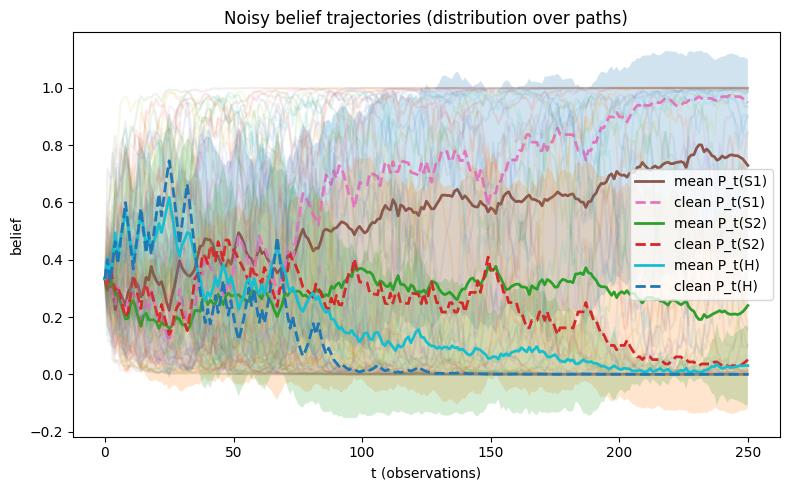

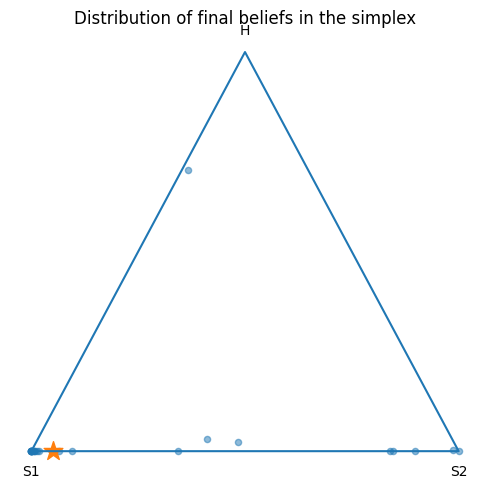

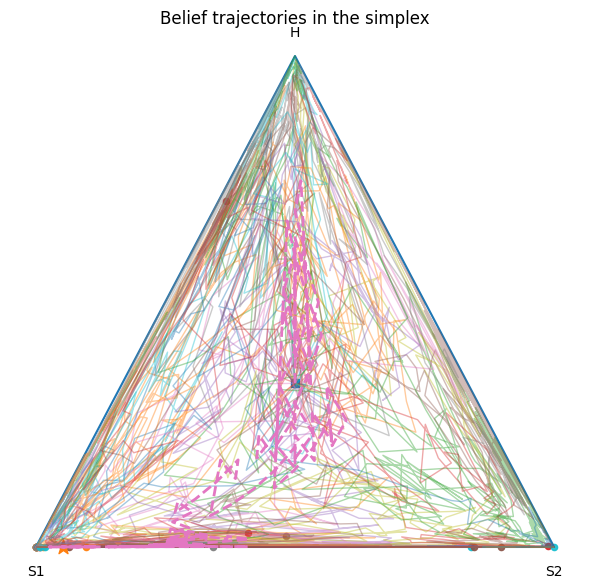

In [ ]:
# Three-State Belief Simulation with Noisy Log-Space Updates
# Yurui Zi
# Extended with ensemble + simplex trajectory plotting

import numpy as np
import matplotlib.pyplot as plt

# -------------------- Core Model --------------------

STATES = ["S1", "S2", "H"]
SIGS   = ["cough", "scratch", "whistle"]

def check_params(a, b, c):
    assert 0 <= a <= 1 and 0 <= b <= 1 and 0 <= c <= 1, "a,b,c must be in [0,1]"
    assert a + b <= 1, "need a + b ≤ 1"
    assert 2*c <= 1, "need 2c ≤ 1"

# Returns l(x) = [P(x|S1), P(x|S2), P(x|H)] in the order [S1,S2,H].
def likelihood_vector(x, a, b, c):
    if x == "cough":
        return np.array([a, b, c], dtype=float)
    elif x == "scratch":
        return np.array([b, a, c], dtype=float)
    elif x == "whistle":
        return np.array([1-(a+b), 1-(a+b), 1-2*c], dtype=float)
    else:
        raise ValueError("x must be one of {'cough','scratch','whistle'}")

# Samples x_t from P(x|true_state)
def sample_observation(true_state, a, b, c, rng):
    if true_state == "S1":
        probs = [a, b, 1-(a+b)]
    elif true_state == "S2":
        probs = [b, a, 1-(a+b)]
    elif true_state == "H":
        probs = [c, c, 1-2*c]
    else:
        raise ValueError("true_state must be 'S1', 'S2', or 'H'")
    return rng.choice(SIGS, p=probs)

# Standard Bayes update (no noise), in probability space
def bayes_update(p_prev, x, a, b, c):
    """p_t = (p_{t-1} ⊙ l(x)) / <p_{t-1}, l(x)>"""
    l = likelihood_vector(x, a, b, c)
    num = p_prev * l
    den = float(np.dot(p_prev, l))
    if den == 0:
        raise ZeroDivisionError("Predictive probability is zero; check parameters.")
    return num / den

def run_sim(T=50, a=0.5, b=0.2, c=0.1, prior=None, true_state=None, seed=0):
    """
    Simulate T i.i.d. observations from a fixed true_state and update beliefs over time.
    - prior: length-3 array for [S1,S2,H]; default uniform.
    - true_state: 'S1'/'S2'/'H' or None -> sampled from prior.
    """
    check_params(a, b, c)
    rng = np.random.default_rng(seed)
    if prior is None:
        prior = np.ones(3) / 3
    prior = np.asarray(prior, dtype=float)
    prior = prior / prior.sum()

    if true_state is None:
        true_state = rng.choice(STATES, p=prior)

    p_traj = np.zeros((T+1, 3))
    p_traj[0] = prior.copy()
    xs = []

    p = prior.copy()
    for t in range(1, T+1):
        x = sample_observation(true_state, a, b, c, rng)
        xs.append(x)
        p = bayes_update(p, x, a, b, c)
        p_traj[t] = p

    return {
        "true_state": true_state,
        "observations": xs,
        "p_traj": p_traj,  # rows 0..T, columns [S1,S2,H]
        "params": (a, b, c)
    }

def plot_beliefs(sim):
    T = sim["p_traj"].shape[0] - 1
    plt.figure(figsize=(7,4))
    for i, s in enumerate(STATES):
        plt.plot(range(T+1), sim["p_traj"][:, i], label=f"P_t({s})")
    plt.xlabel("t (observations)")
    plt.ylabel("belief")
    plt.title(f"Belief trajectory (true state = {sim['true_state']})")
    plt.legend()
    plt.tight_layout()
    plt.show()

# -------------------- Log-Space + Noise Machinery --------------------

def logsumexp_vec(log_p):
    """Stable log-sum-exp for 1D array."""
    m = np.max(log_p)
    return m + np.log(np.sum(np.exp(log_p - m)))

def prior_to_log_prior(prior):
    prior = np.asarray(prior, dtype=float)
    prior = prior / prior.sum()
    return np.log(prior + 1e-15)  # protect against log(0)

def noisy_log_update(log_p_prev, x, a, b, c, sigma, rng):
    """
    One noisy Bayes update in log-space:

    log_p_t = log_p_{t-1} + log l(x_t) + eps,
    eps ~ N(0, sigma^2 I_3),

    then normalize back to a probability vector.
    """
    l = likelihood_vector(x, a, b, c)
    log_l = np.log(l + 1e-15)
    eps = rng.normal(loc=0.0, scale=sigma, size=3)

    log_p = log_p_prev + log_l + eps
    logZ = logsumexp_vec(log_p)
    log_p_norm = log_p - logZ
    p = np.exp(log_p_norm)
    return log_p_norm, p

# -------------------- Fixed Sequence + Ensemble --------------------

def generate_fixed_sequence(T=50, a=0.3, b=0.29, c=0.2,
                            prior=None, true_state="S1", seed=0):
    """
    Use the clean simulator to:
      - fix a true state (if given)
      - generate a single observation sequence of length T
      - return the 'clean' (noise-free) belief trajectory
    """
    sim = run_sim(
        T=T,
        a=a, b=b, c=c,
        prior=prior,
        true_state=true_state,
        seed=seed
    )
    return sim  # has: true_state, observations, p_traj, params

def simulate_noisy_ensemble(observations, a, b, c,
                            prior=None, n_paths=100, sigma=0.2, seed=123):
    """
    Given a fixed observation sequence, run many noisy log-space trajectories.

    observations: list of strings x_1,...,x_T
    Returns:
      p_trajs: shape (n_paths, T+1, 3) for [S1,S2,H].
    """
    if prior is None:
        prior = np.ones(3) / 3
    prior = np.asarray(prior, dtype=float)
    prior = prior / prior.sum()

    T = len(observations)
    rng = np.random.default_rng(seed)

    p_trajs = np.zeros((n_paths, T+1, 3))
    log_p0 = prior_to_log_prior(prior)

    for k in range(n_paths):
        log_p = log_p0.copy()
        p = prior.copy()
        p_trajs[k, 0] = p

        for t, x in enumerate(observations, start=1):
            log_p, p = noisy_log_update(log_p, x, a, b, c, sigma, rng)
            p_trajs[k, t] = p

    return p_trajs

# -------------------- Time-Series & Simplex Plots --------------------

def plot_ensemble_time(p_trajs, clean_traj=None):
    """
    Plot noisy ensemble over time:
      - many faint trajectories
      - mean ± std band
      - optional clean (noise-free) trajectory
    """
    n_paths, T_plus_1, _ = p_trajs.shape
    T = T_plus_1 - 1
    ts = np.arange(T_plus_1)

    mean_traj = p_trajs.mean(axis=0)
    std_traj  = p_trajs.std(axis=0)

    plt.figure(figsize=(8, 5))

    for i, s in enumerate(STATES):
        # Faint individual trajectories (subset)
        for k in range(min(n_paths, 30)):
            plt.plot(ts, p_trajs[k, :, i], alpha=0.1)

        # Mean + std band
        plt.plot(ts, mean_traj[:, i], label=f"mean P_t({s})", linewidth=2)
        plt.fill_between(ts,
                         mean_traj[:, i] - std_traj[:, i],
                         mean_traj[:, i] + std_traj[:, i],
                         alpha=0.2)

        # Clean trajectory overlay
        if clean_traj is not None:
            plt.plot(ts, clean_traj[:, i],
                     linestyle="--", linewidth=2,
                     label=f"clean P_t({s})")

    plt.xlabel("t (observations)")
    plt.ylabel("belief")
    plt.title("Noisy belief trajectories (distribution over paths)")
    plt.legend()
    plt.tight_layout()
    plt.show()

def probs_to_xy(p):
    """
    Map p = [p1,p2,p3] for [S1,S2,H] to 2D coordinates in an equilateral triangle.

    Vertices:
      S1 -> (0, 0)
      S2 -> (1, 0)
      H  -> (0.5, sqrt(3)/2)
    """
    coords = np.array([
        [0.0, 0.0],                    # S1
        [1.0, 0.0],                    # S2
        [0.5, np.sqrt(3.0) / 2.0]      # H
    ])
    return p @ coords

def plot_final_points_triangle(p_trajs, clean_traj=None):
    """
    Scatter plot of final beliefs (t = T) for all trajectories in the 2-simplex.
    """
    n_paths, T_plus_1, _ = p_trajs.shape
    final_ps = p_trajs[:, -1, :]  # (n_paths, 3)

    xs, ys = [], []
    for p in final_ps:
        x, y = probs_to_xy(p)
        xs.append(x)
        ys.append(y)

    plt.figure(figsize=(5, 5))

    # Draw triangle boundary
    tri = np.array([
        [0.0, 0.0],                    # S1
        [1.0, 0.0],                    # S2
        [0.5, np.sqrt(3.0) / 2.0],     # H
        [0.0, 0.0]
    ])
    plt.plot(tri[:, 0], tri[:, 1])

    # Final points
    plt.scatter(xs, ys, alpha=0.5, s=20)

    # Mark clean final belief
    if clean_traj is not None:
        p_clean_final = clean_traj[-1, :]
        x_clean, y_clean = probs_to_xy(p_clean_final)
        plt.scatter([x_clean], [y_clean], marker="*", s=200)

    # Vertex labels
    plt.text(0.0, -0.03, "S1", ha="center", va="top")
    plt.text(1.0, -0.03, "S2", ha="center", va="top")
    plt.text(0.5, np.sqrt(3.0)/2 + 0.03, "H", ha="center", va="bottom")

    plt.title("Distribution of final beliefs in the simplex")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_trajectories_triangle(p_trajs, clean_traj=None, max_paths=50):
    """
    Plot full belief trajectories in the 2-simplex.

    p_trajs: (n_paths, T+1, 3)
    clean_traj: optional (T+1, 3) noise-free trajectory
    max_paths: max number of noisy paths to draw
    """
    n_paths, T_plus_1, _ = p_trajs.shape

    # Triangle vertices
    tri = np.array([
        [0.0, 0.0],                    # S1
        [1.0, 0.0],                    # S2
        [0.5, np.sqrt(3.0) / 2.0],     # H
        [0.0, 0.0]
    ])

    plt.figure(figsize=(6, 6))

    # Triangle boundary
    plt.plot(tri[:, 0], tri[:, 1])

    # Noisy trajectories
    n_to_plot = min(n_paths, max_paths)
    for k in range(n_to_plot):
        traj = p_trajs[k]  # (T+1, 3)
        coords = np.apply_along_axis(probs_to_xy, 1, traj)  # (T+1, 2)
        plt.plot(coords[:, 0], coords[:, 1], alpha=0.4, linewidth=1)

        # Mark start & end
        plt.scatter(coords[0, 0], coords[0, 1], s=15, alpha=0.6)
        plt.scatter(coords[-1, 0], coords[-1, 1], s=20, alpha=0.9)

    # Clean trajectory
    if clean_traj is not None:
        clean_coords = np.apply_along_axis(probs_to_xy, 1, clean_traj)
        plt.plot(clean_coords[:, 0], clean_coords[:, 1],
                 linestyle="--", linewidth=2)
        plt.scatter(clean_coords[0, 0], clean_coords[0, 1],
                    marker="s", s=40)
        plt.scatter(clean_coords[-1, 0], clean_coords[-1, 1],
                    marker="*", s=120)

    # Labels
    plt.text(0.0, -0.03, "S1", ha="center", va="top")
    plt.text(1.0, -0.03, "S2", ha="center", va="top")
    plt.text(0.5, np.sqrt(3.0)/2 + 0.03, "H", ha="center", va="bottom")

    plt.title("Belief trajectories in the simplex")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# -------------------- Example Run --------------------

if __name__ == "__main__":
    # 1. Fix a sequence and get clean trajectory
    base_sim = generate_fixed_sequence(
        T=250,
        a=0.3, b=0.25, c=0.2,         # satisfies constraints
        prior=[1/3, 1/3, 1/3],
        true_state="S1",
        seed=42
    )

    observations = base_sim["observations"]
    clean_traj   = base_sim["p_traj"]
    a, b, c      = base_sim["params"]

    # 2. Simulate many noisy trajectories for that fixed sequence
    p_trajs = simulate_noisy_ensemble(
        observations,
        a=a, b=b, c=c,
        prior=[1/3, 1/3, 1/3],
        n_paths=25,
        sigma=0.3,      # noise level in log space
        seed=123
    )

    # 3. Time-series distribution view
    plot_ensemble_time(p_trajs, clean_traj=clean_traj)

    # 4. Final distribution in simplex
    plot_final_points_triangle(p_trajs, clean_traj=clean_traj)

    # 5. Full trajectories in simplex
    plot_trajectories_triangle(p_trajs, clean_traj=clean_traj, max_paths=60)



Final S1 belief distribution:
0.0–0.2: 50 paths (25.0%)
0.2–0.4: 6 paths (3.0%)
0.4–0.6: 14 paths (7.0%)
0.6–0.8: 11 paths (5.5%)
0.8–1.0: 119 paths (59.5%)


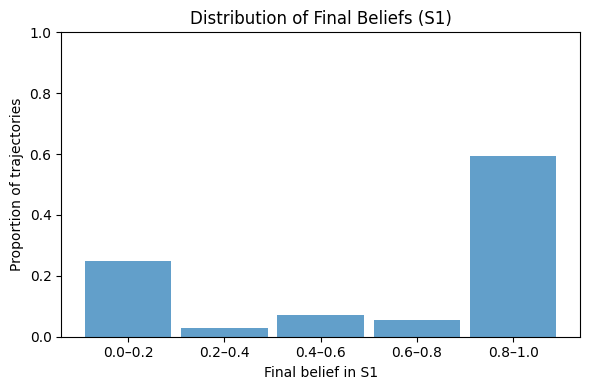

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Core Model --------------------

STATES = ["S1", "S2", "H"]
SIGS   = ["cough", "scratch", "whistle"]

def check_params(a, b, c):
    assert 0 <= a <= 1 and 0 <= b <= 1 and 0 <= c <= 1, "a,b,c must be in [0,1]"
    assert a + b <= 1, "need a + b ≤ 1"
    assert 2*c <= 1, "need 2c ≤ 1"

def likelihood_vector(x, a, b, c):
    if x == "cough":
        return np.array([a, b, c], dtype=float)
    elif x == "scratch":
        return np.array([b, a, c], dtype=float)
    elif x == "whistle":
        return np.array([1-(a+b), 1-(a+b), 1-2*c], dtype=float)
    else:
        raise ValueError("x must be one of {'cough','scratch','whistle'}")

def sample_observation(true_state, a, b, c, rng):
    if true_state == "S1":
        probs = [a, b, 1-(a+b)]
    elif true_state == "S2":
        probs = [b, a, 1-(a+b)]
    else:
        probs = [c, c, 1-2*c]
    return rng.choice(SIGS, p=probs)

def bayes_update(p_prev, x, a, b, c):
    l = likelihood_vector(x, a, b, c)
    num = p_prev * l
    den = float(np.dot(p_prev, l))
    return num / den

def run_sim(T=50, a=0.5, b=0.2, c=0.1, prior=None, true_state=None, seed=0):
    check_params(a, b, c)
    rng = np.random.default_rng(seed)
    if prior is None:
        prior = np.ones(3) / 3
    prior = np.asarray(prior, dtype=float)

    if true_state is None:
        true_state = rng.choice(STATES, p=prior)

    p_traj = np.zeros((T+1, 3))
    p_traj[0] = prior.copy()
    xs = []

    p = prior.copy()
    for t in range(1, T+1):
        x = sample_observation(true_state, a, b, c, rng)
        xs.append(x)
        p = bayes_update(p, x, a, b, c)
        p_traj[t] = p

    return {
        "true_state": true_state,
        "observations": xs,
        "p_traj": p_traj,
        "params": (a, b, c)
    }

# -------------------- Log-Space Noisy Updates --------------------

def logsumexp_vec(log_p):
    m = np.max(log_p)
    return m + np.log(np.sum(np.exp(log_p - m)))

def prior_to_log_prior(prior):
    return np.log(prior + 1e-15)

def noisy_log_update(log_p_prev, x, a, b, c, sigma, rng):
    log_l = np.log(likelihood_vector(x, a, b, c) + 1e-15)
    eps = rng.normal(0, sigma, 3)
    log_p = log_p_prev + log_l + eps
    logZ = logsumexp_vec(log_p)
    log_p_norm = log_p - logZ
    p = np.exp(log_p_norm)
    return log_p_norm, p

# -------------------- Fixed Sequence + Ensemble --------------------

def generate_fixed_sequence(T=50, a=0.3, b=0.29, c=0.2,
                            prior=None, true_state="S1", seed=0):

    sim = run_sim(
        T=T, a=a, b=b, c=c,
        prior=prior,
        true_state=true_state,
        seed=seed
    )
    return sim

def simulate_noisy_ensemble(observations, a, b, c,
                            prior=None, n_paths=100, sigma=0.2, seed=123):

    if prior is None:
        prior = np.ones(3) / 3
    prior = np.asarray(prior, dtype=float)

    T = len(observations)
    rng = np.random.default_rng(seed)

    p_trajs = np.zeros((n_paths, T+1, 3))
    log_p0 = prior_to_log_prior(prior)

    for k in range(n_paths):
        log_p = log_p0.copy()
        p = prior.copy()
        p_trajs[k, 0] = p

        for t, x in enumerate(observations, start=1):
            log_p, p = noisy_log_update(log_p, x, a, b, c, sigma, rng)
            p_trajs[k, t] = p

    return p_trajs

# -------------------- POLARIZATION DISTRIBUTION (NEW) --------------------

def plot_final_distribution_S1(p_trajs, bins=None):
    """
    Create a distribution over final S1 beliefs.
    Example bins: [0.0,0.2,0.4,0.6,0.8,1.0]
    """

    if bins is None:
        bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

    final_S1 = p_trajs[:, -1, 0]  # extract P(S1) final beliefs
    hist, edges = np.histogram(final_S1, bins=bins)
    proportions = hist / hist.sum()

    print("\nFinal S1 belief distribution:")
    for i in range(len(bins)-1):
        print(f"{bins[i]:.1f}–{bins[i+1]:.1f}: "
              f"{hist[i]} paths ({proportions[i]*100:.1f}%)")

    # Plot
    centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]
    plt.figure(figsize=(6, 4))
    plt.bar(centers, proportions, width=0.18, alpha=0.7)
    plt.xlabel("Final belief in S1")
    plt.ylabel("Proportion of trajectories")
    plt.title("Distribution of Final Beliefs (S1)")
    plt.xticks(centers, [f"{bins[i]}–{bins[i+1]}" for i in range(len(bins)-1)])
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    return proportions

# -------------------- Example Run --------------------

if __name__ == "__main__":
    # 1. Clean (noise-free) run to generate a fixed sequence
    base_sim = generate_fixed_sequence(
        T=250,
        a=0.3, b=0.25, c=0.2,
        prior=[1/3, 1/3, 1/3],
        true_state="S1",
        seed=42
    )

    observations = base_sim["observations"]
    clean_traj = base_sim["p_traj"]
    a, b, c = base_sim["params"]

    # 2. Noisy ensemble
    p_trajs = simulate_noisy_ensemble(
        observations,
        a=a, b=b, c=c,
        prior=[1/3, 1/3, 1/3],
        n_paths=200,
        sigma=0.3,
        seed=123
    )

    # 3. NEW: plot distribution over final S1 beliefs
    plot_final_distribution_S1(p_trajs)

